#### 연령별 인구현황 피라미드
- 연령별 인구현황 검색해서 자료 수집

##### 판다스, 맵플롯립, 맵플롯립 한글 설정

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
## 맷플롯립 한글 설정
# matplotlib.rcParams['font.family'] = 'Malgun Gothic'
# matplotlib.rcParams['font.size'] = 15
# matplotlib.rcParams['axes.unicode_minus'] = False
import koreanize_matplotlib # 맷플롯립 한글 설정 대신 사용

- 파일 이름 설정

In [21]:
filename = '201601_201601_연령별인구현황_월간.xlsx'

- 남자 데이터 파일 읽어오기(skiprows, usecols, index_col)

In [23]:
df_m = pd.read_excel(filename, skiprows=3, usecols='b, e:y', index_col='행정기관')
df_m.head(3)
# 엑셀파일이 표준이랑 다르다는 에러 메시지가 뜰수 있으나 문제되는 사항이 아님

/opt/anaconda3/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,0~4세,5~9세,10~14세,15~19세,20~24세,25~29세,30~34세,35~39세,40~44세,45~49세,...,55~59세,60~64세,65~69세,70~74세,75~79세,80~84세,85~89세,90~94세,95~99세,100세 이상
행정기관,,,,,,,,,,,,,,,,,,,,,
전국,"1,155,577","1,206,856","1,269,868","1,696,258","1,884,688","1,641,633","1,902,777","2,008,358","2,233,150","2,277,374",...,"2,031,839","1,424,146","1,058,511","799,513","567,225","291,133","104,773","31,627","7,069","3,832"
서울특별시,"200,437","200,281","214,007","292,742","354,609","367,513","427,894","407,957","429,079","420,928",...,"379,307","281,099","215,133","163,076","103,961","48,818","18,186","5,988","1,781","1,314"
부산광역시,"69,107","68,321","74,000","106,423","130,628","110,048","122,708","129,049","138,324","144,608",...,"154,315","120,314","88,623","64,233","41,545","19,081","6,255","1,733",370,322


In [11]:
df_m.iloc[0]

0~4세       1,155,577
5~9세       1,206,856
10~14세     1,269,868
15~19세     1,696,258
20~24세     1,884,688
25~29세     1,641,633
30~34세     1,902,777
35~39세     2,008,358
40~44세     2,233,150
45~49세     2,277,374
50~54세     2,167,030
55~59세     2,031,839
60~64세     1,424,146
65~69세     1,058,511
70~74세       799,513
75~79세       567,225
80~84세       291,133
85~89세       104,773
90~94세        31,627
95~99세         7,069
100세 이상        3,832
Name: 전국  , dtype: object

In [13]:
df_m.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18 entries, 전국   to 제주특별자치도  
Data columns (total 21 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   0~4세     18 non-null     object
 1   5~9세     18 non-null     object
 2   10~14세   18 non-null     object
 3   15~19세   18 non-null     object
 4   20~24세   18 non-null     object
 5   25~29세   18 non-null     object
 6   30~34세   18 non-null     object
 7   35~39세   18 non-null     object
 8   40~44세   18 non-null     object
 9   45~49세   18 non-null     object
 10  50~54세   18 non-null     object
 11  55~59세   18 non-null     object
 12  60~64세   18 non-null     object
 13  65~69세   18 non-null     object
 14  70~74세   18 non-null     object
 15  75~79세   18 non-null     object
 16  80~84세   18 non-null     object
 17  85~89세   18 non-null     object
 18  90~94세   18 non-null     object
 19  95~99세   18 non-null     object
 20  100세 이상  18 non-null     object
dtypes: object(21)
memory usage: 3.1+ KB


- 전국 인구 (콤마), 제외하고 숫자로 변환

In [17]:
# 남자인구의 모든 데이터 콤마 제외 - 전국인구만 제외하면 되지만 그냥 한번 해봄 ㅡ.ㅡ;
# 모든 컬럼에 대해 반복하며 콤마(,)를 빈 문자열('')로 바꾸고 숫자로 변환
for col in df_m.columns:
    if df_m[col].dtype == 'object': # 데이터 타입이 문자열인 경우에만
        df_m[col] = df_m[col].str.replace(',', '').astype(int)
df_m

,0~4세,5~9세,10~14세,15~19세,20~24세,25~29세,30~34세,35~39세,40~44세,45~49세,...,55~59세,60~64세,65~69세,70~74세,75~79세,80~84세,85~89세,90~94세,95~99세,100세 이상
행정기관,,,,,,,,,,,,,,,,,,,,,
전국,1155577,1206856,1269868,1696258,1884688,1641633,1902777,2008358,2233150,2277374,...,2031839,1424146,1058511,799513,567225,291133,104773,31627,7069,3832
서울특별시,200437,200281,214007,292742,354609,367513,427894,407957,429079,420928,...,379307,281099,215133,163076,103961,48818,18186,5988,1781,1314
부산광역시,69107,68321,74000,106423,130628,110048,122708,129049,138324,144608,...,154315,120314,88623,64233,41545,19081,6255,1733,370,322
대구광역시,51628,55431,63634,89147,99981,79397,82404,89552,104114,112145,...,99263,70412,50774,36848,25794,13261,4182,1090,219,120
인천광역시,68866,70417,71572,95560,111748,97508,113425,120552,130336,130859,...,119223,74874,52847,37063,24389,12470,4668,1588,386,194
광주광역시,34868,39140,43168,58806,59220,44364,53049,57583,64238,64513,...,50537,33690,27147,19914,12990,6599,2444,640,107,35
대전광역시,36201,38095,41072,54756,59993,51892,56390,58602,66116,67366,...,57342,38814,27470,19836,13308,6938,2560,764,187,65
울산광역시,30124,29911,30699,43305,48532,40540,46004,48671,50300,55749,...,48634,31593,20239,12531,7484,3477,1111,270,70,26
세종특별자치시,7721,7910,6546,5720,6110,5896,8874,10984,11595,9013,...,6469,4590,3282,2472,1941,1082,419,119,13,9


In [11]:
df_m.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18 entries, 전국   to 제주특별자치도  
Data columns (total 21 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   0~4세     18 non-null     object
 1   5~9세     18 non-null     object
 2   10~14세   18 non-null     object
 3   15~19세   18 non-null     object
 4   20~24세   18 non-null     object
 5   25~29세   18 non-null     object
 6   30~34세   18 non-null     object
 7   35~39세   18 non-null     object
 8   40~44세   18 non-null     object
 9   45~49세   18 non-null     object
 10  50~54세   18 non-null     object
 11  55~59세   18 non-null     object
 12  60~64세   18 non-null     object
 13  65~69세   18 non-null     object
 14  70~74세   18 non-null     object
 15  75~79세   18 non-null     object
 16  80~84세   18 non-null     object
 17  85~89세   18 non-null     object
 18  90~94세   18 non-null     object
 19  95~99세   18 non-null     object
 20  100세 이상  18 non-null     object
dtypes: object(21)
memory usage: 3.1+ KB


In [25]:
# 남자인구의 전국 데이터만 콤마 제외 - 제외 한것을 재실행하면 에러발생
df_m.iloc[0]=df_m.iloc[0].str.replace(',','').astype(int)

In [27]:
df_m.iloc[0]

0~4세       1155577
5~9세       1206856
10~14세     1269868
15~19세     1696258
20~24세     1884688
25~29세     1641633
30~34세     1902777
35~39세     2008358
40~44세     2233150
45~49세     2277374
50~54세     2167030
55~59세     2031839
60~64세     1424146
65~69세     1058511
70~74세      799513
75~79세      567225
80~84세      291133
85~89세      104773
90~94세       31627
95~99세        7069
100세 이상       3832
Name: 전국  , dtype: object

- 여자 데이터 파일 읽어오기

In [29]:
df_w = pd.read_excel(filename, skiprows=3, usecols='b, ab:av', index_col='행정기관')
df_w.head(3)

/opt/anaconda3/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,0~4세.1,5~9세.1,10~14세.1,15~19세.1,20~24세.1,25~29세.1,30~34세.1,35~39세.1,40~44세.1,45~49세.1,...,55~59세.1,60~64세.1,65~69세.1,70~74세.1,75~79세.1,80~84세.1,85~89세.1,90~94세.1,95~99세.1,100세 이상.1
행정기관,,,,,,,,,,,,,,,,,,,,,
전국,"1,097,056","1,135,460","1,173,465","1,550,918","1,669,493","1,501,433","1,810,248","1,932,966","2,152,314","2,207,501",...,"2,031,127","1,481,190","1,149,146","983,169","824,732","554,416","285,345","103,656","24,808","12,550"
서울특별시,"190,626","189,969","200,408","272,485","348,361","376,047","424,773","404,376","427,085","425,947",...,"409,171","308,243","240,138","183,638","132,504","82,714","44,692","17,357","4,820","3,770"
부산광역시,"65,250","64,532","68,320","94,820","114,039","101,545","117,395","123,557","136,822","148,572",...,"165,289","129,494","97,584","75,444","58,405","36,130","18,377","6,130","1,381","1,175"


- 남자 데이터와 여자 데이터 컬럼명 일치시키기

In [31]:
df_w.columns = df_m.columns

In [18]:
df_w.columns

Index(['0~4세', '5~9세', '10~14세', '15~19세', '20~24세', '25~29세', '30~34세',
       '35~39세', '40~44세', '45~49세', '50~54세', '55~59세', '60~64세', '65~69세',
       '70~74세', '75~79세', '80~84세', '85~89세', '90~94세', '95~99세', '100세 이상'],
      dtype='object')

- 전국 인구 (콤마), 제외하고 숫자로 변환

In [33]:
# 여자인구의 전국 데이터만 콤마 제외 - 제외 한것을 재실행하면 에러발생
df_w.iloc[0]=df_w.iloc[0].str.replace(',','').astype(int)

In [35]:
df_w.iloc[0]

0~4세       1097056
5~9세       1135460
10~14세     1173465
15~19세     1550918
20~24세     1669493
25~29세     1501433
30~34세     1810248
35~39세     1932966
40~44세     2152314
45~49세     2207501
50~54세     2097352
55~59세     2031127
60~64세     1481190
65~69세     1149146
70~74세      983169
75~79세      824732
80~84세      554416
85~89세      285345
90~94세      103656
95~99세       24808
100세 이상      12550
Name: 전국  , dtype: object

- 인구 피라미드 시각화, 크기( 15, 9 ), barh, 제목(2016년 인구 피라미드), png 파일 저장

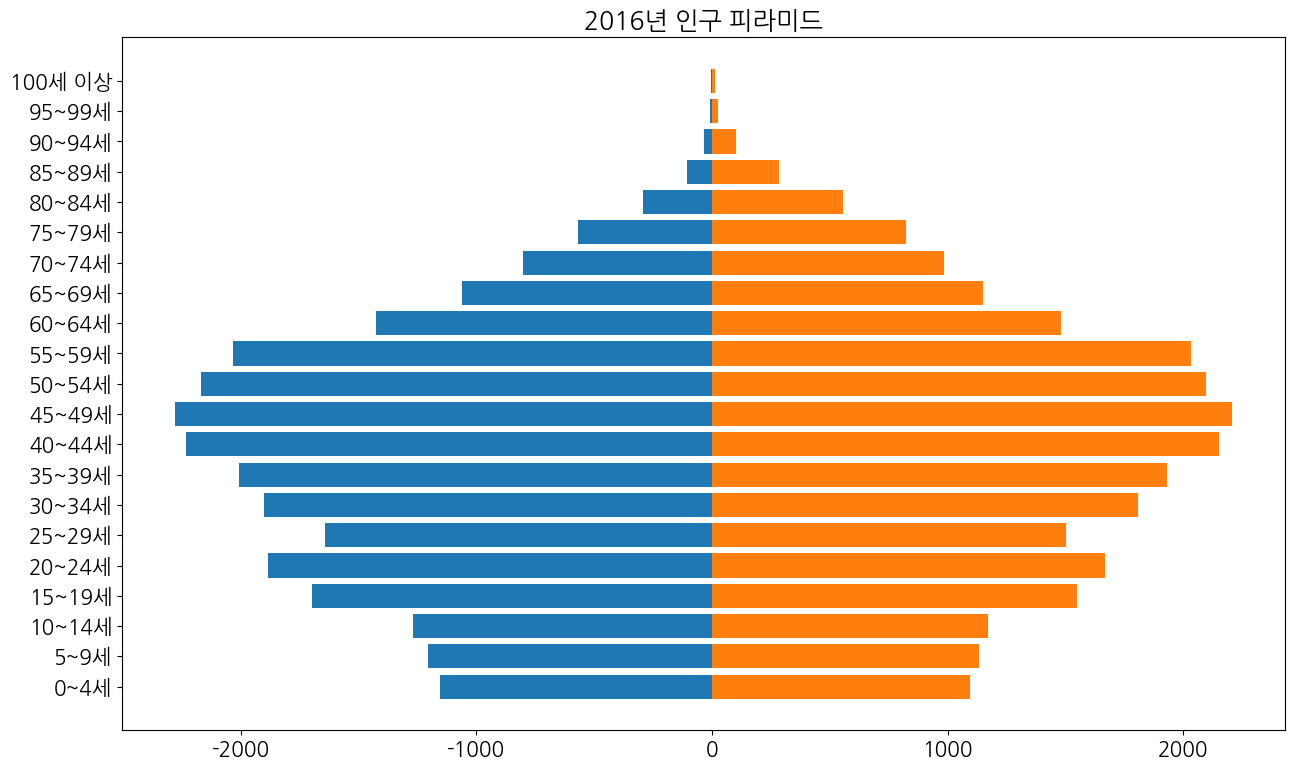

In [41]:
plt.figure(figsize=(15,9))
plt.barh(df_m.columns, -df_m.iloc[0] // 1000)
plt.barh(df_w.columns, df_w.iloc[0] // 1000)
plt.title('2016년 인구 피라미드')
plt.savefig('2016년 인구 피라미드.png', dpi=100)
plt.show()

- 2026년 인구 통계 분석

- 파일 이름 설정

In [43]:
filename = '202601_202601_연령별인구현황_월간.xlsx'

In [45]:
df2026_m = pd.read_excel(filename, skiprows=3, usecols='b, e:y', index_col='행정기관')
df2026_m.iloc[0]=df2026_m.iloc[0].str.replace(',','').astype(int)
df2026_w = pd.read_excel(filename, skiprows=3, usecols='b, ab:av', index_col='행정기관')
df2026_w.columns = df2026_m.columns
df2026_w.iloc[0]=df2026_w.iloc[0].str.replace(',','').astype(int)

/opt/anaconda3/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/opt/anaconda3/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


- 위에서 작업한 내용 종합해서 2026년 인구 피라미드 작성

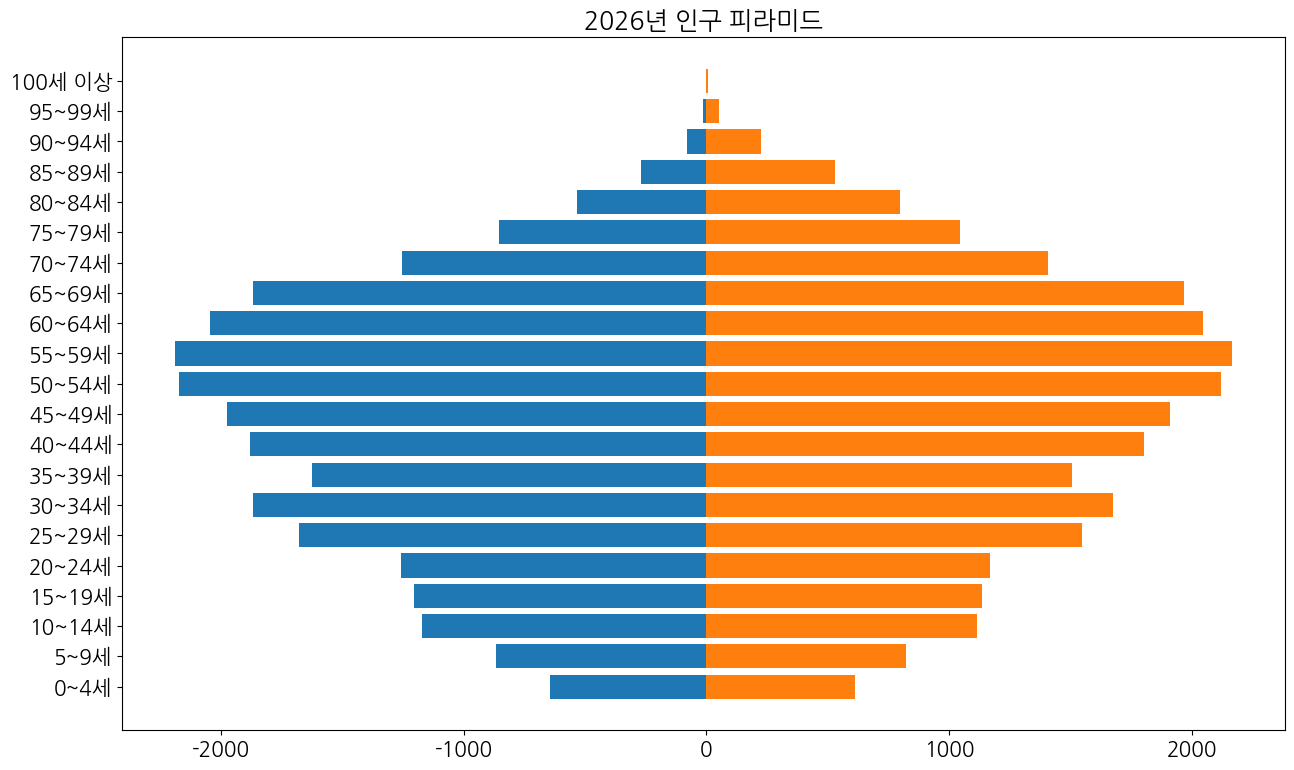

In [47]:
plt.figure(figsize=(15,9))
plt.barh(df2026_m.columns, -df2026_m.iloc[0] // 1000)
plt.barh(df2026_w.columns, df2026_w.iloc[0] // 1000)
plt.title('2026년 인구 피라미드')
plt.savefig('2026년 인구 피라미드.png', dpi=100)
plt.show()